# EDA: Yandex Yambda 50M

Explores interaction-count distributions, user activity, item popularity long-tail, sparsity, and temporal patterns.  
Findings feed into preprocessing thresholds and the positive-label definition for the two-tower model.

In [1]:
import sys
sys.path.insert(0, "..")  # make src/ importable from notebooks/

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data.load import load_interactions

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("Loading likes...")
likes = load_interactions("likes", size="50m", fmt="flat", root="../data/raw")
print(f"  likes: {likes.shape}")

print("Loading listens...")
listens = load_interactions("listens", size="50m", fmt="flat", root="../data/raw")
print(f"  listens: {listens.shape}")

Loading likes...


  likes: (881456, 4)
Loading listens...


  listens: (46467212, 6)


## 1. Dataset Overview

In [2]:
for name, df in [("likes", likes), ("listens", listens)]:
    print(f"\n=== {name} ===")
    print(f"Shape:   {df.shape}")
    print(f"Memory:  {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
    print(f"Dtypes:\n{df.dtypes}")
    print(f"\nNull counts:\n{df.isnull().sum()}")
    print(f"\nBasic stats:\n{df.describe()}")


=== likes ===
Shape:   (881456, 4)
Memory:  11.5 MB
Dtypes:
uid           uint32
timestamp     uint32
item_id       uint32
is_organic     uint8
dtype: object

Null counts:
uid           0
timestamp     0
item_id       0
is_organic    0
dtype: int64

Basic stats:
                  uid     timestamp       item_id     is_organic
count   881456.000000  8.814560e+05  8.814560e+05  881456.000000
mean    504442.953364  1.449540e+07  4.707556e+06       0.569740
std     288425.773579  7.740868e+06  2.704587e+06       0.495113
min        100.000000  8.000000e+01  2.600000e+01       0.000000
25%     255600.000000  7.751601e+06  2.381020e+06       0.000000
50%     510400.000000  1.541102e+07  4.714327e+06       1.000000
75%     763700.000000  2.145078e+07  7.041449e+06       1.000000
max    1000000.000000  2.599997e+07  9.390522e+06       1.000000

=== listens ===
Shape:   (46467212, 6)
Memory:  882.9 MB
Dtypes:
uid                     uint32
timestamp               uint32
item_id                


Null counts:
uid                     0
timestamp               0
item_id                 0
is_organic              0
played_ratio_pct        0
track_length_seconds    0
dtype: int64



Basic stats:
                uid     timestamp       item_id    is_organic  \
count  4.646721e+07  4.646721e+07  4.646721e+07  4.646721e+07   
mean   4.984990e+05  1.444838e+07  4.713864e+06  5.165719e-01   
std    2.873001e+05  7.463942e+06  2.701184e+06  4.997253e-01   
min    1.000000e+02  0.000000e+00  2.200000e+01  0.000000e+00   
25%    2.494000e+05  8.207915e+06  2.396488e+06  0.000000e+00   
50%    4.942000e+05  1.508945e+07  4.715228e+06  1.000000e+00   
75%    7.446000e+05  2.105715e+07  7.050175e+06  1.000000e+00   
max    1.000000e+06  2.600000e+07  9.390623e+06  1.000000e+00   

       played_ratio_pct  track_length_seconds  
count      4.646721e+07          4.646721e+07  
mean       6.475949e+01          2.074118e+02  
std        4.408853e+01          8.921089e+01  
min        0.000000e+00          5.000000e+00  
25%        7.000000e+00          1.650000e+02  
50%        1.000000e+02          2.000000e+02  
75%        1.000000e+02          2.300000e+02  
max        1.590

In [3]:
for name, df in [("likes", likes), ("listens", listens)]:
    n_users = df["uid"].nunique()
    n_items = df["item_id"].nunique()
    n_rows  = len(df)
    print(f"{name}: {n_rows:,} interactions | {n_users:,} users | {n_items:,} items")

likes: 881,456 interactions | 8,283 users | 181,304 items


listens: 46,467,212 interactions | 9,238 users | 877,168 items


## 2. Interaction-Count Distributions

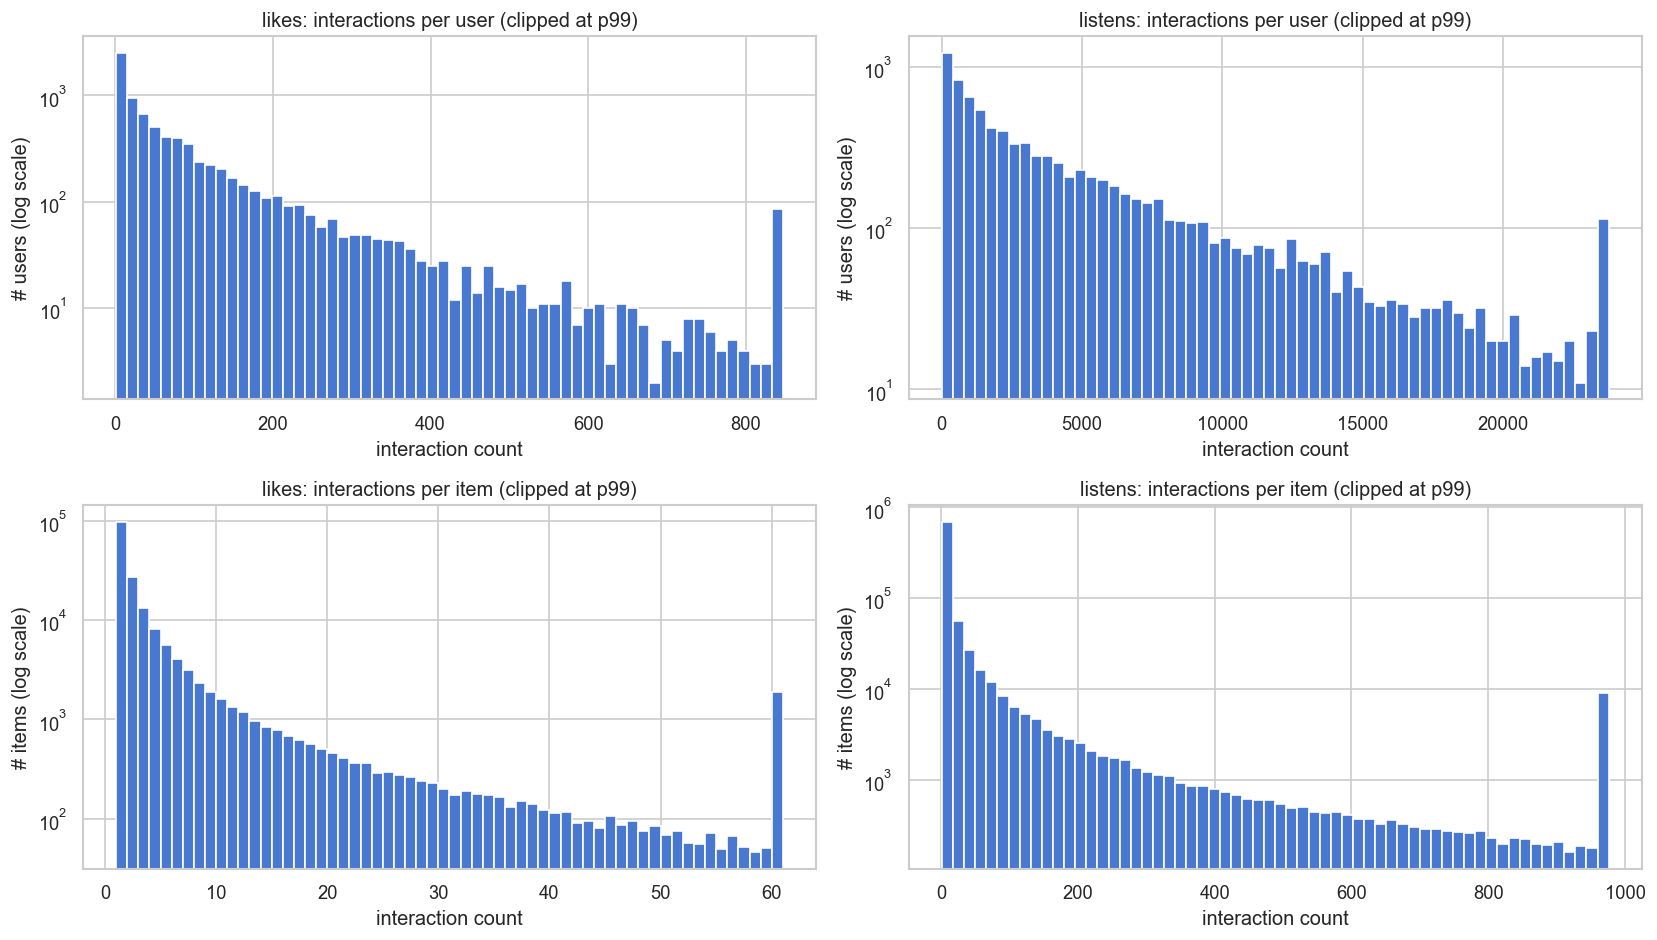

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col_idx, (name, df) in enumerate([("likes", likes), ("listens", listens)]):
    user_counts = df.groupby("uid").size()
    item_counts = df.groupby("item_id").size()

    ax = axes[0, col_idx]
    ax.hist(user_counts.clip(upper=user_counts.quantile(0.99)), bins=60, log=True)
    ax.set_title(f"{name}: interactions per user (clipped at p99)")
    ax.set_xlabel("interaction count")
    ax.set_ylabel("# users (log scale)")

    ax = axes[1, col_idx]
    ax.hist(item_counts.clip(upper=item_counts.quantile(0.99)), bins=60, log=True)
    ax.set_title(f"{name}: interactions per item (clipped at p99)")
    ax.set_xlabel("interaction count")
    ax.set_ylabel("# items (log scale)")

plt.tight_layout()
plt.show()

In [5]:
for name, df in [("likes", likes), ("listens", listens)]:
    user_counts = df.groupby("uid").size()
    item_counts = df.groupby("item_id").size()
    pcts = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    print(f"\n=== {name} ===")
    print("User interaction count percentiles:")
    print(pd.Series(np.percentile(user_counts, pcts), index=[f"p{p}" for p in pcts]).to_string())
    print("\nItem interaction count percentiles:")
    print(pd.Series(np.percentile(item_counts, pcts), index=[f"p{p}" for p in pcts]).to_string())


=== likes ===
User interaction count percentiles:
p1       1.00
p5       1.00
p10      2.00
p25     10.00
p50     44.00
p75    124.00
p90    269.80
p95    398.00
p99    847.08

Item interaction count percentiles:
p1      1.0
p5      1.0
p10     1.0
p25     1.0
p50     1.0
p75     3.0
p90     9.0
p95    18.0
p99    61.0



=== listens ===
User interaction count percentiles:
p1        21.00
p5        97.00
p10      258.00
p25      937.25
p50     3023.50
p75     7182.00
p90    13043.60
p95    17335.90
p99    23765.26

Item interaction count percentiles:
p1       1.0
p5       1.0
p10      1.0
p25      1.0
p50      3.0
p75     12.0
p90     62.0
p95    168.0
p99    976.0


## 3. User Activity

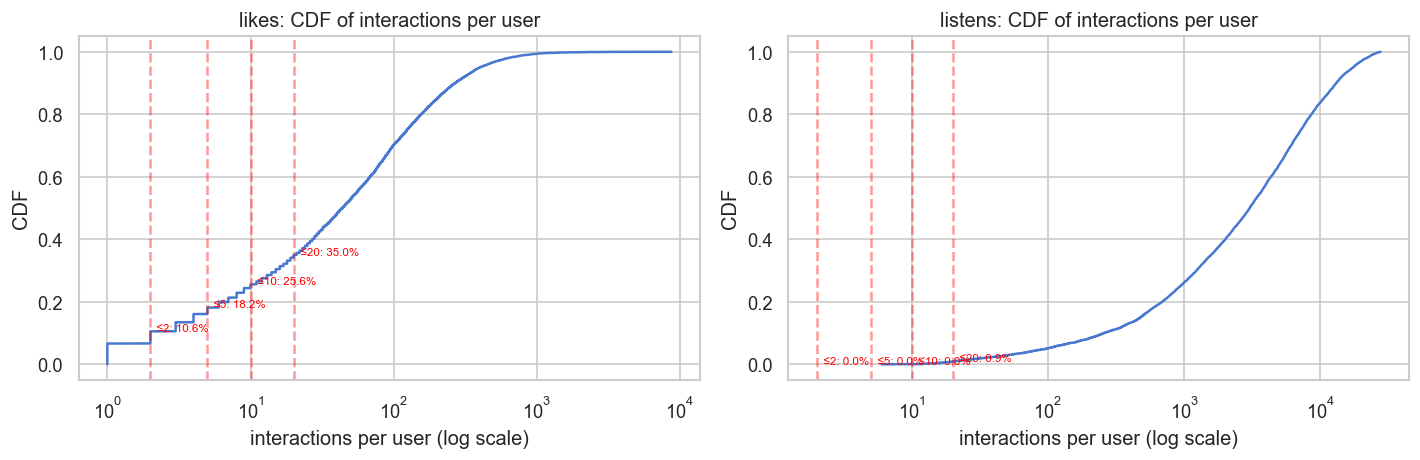

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df) in zip(axes, [("likes", likes), ("listens", listens)]):
    user_counts = df.groupby("uid").size().sort_values()
    cdf = np.arange(1, len(user_counts) + 1) / len(user_counts)
    ax.plot(user_counts.values, cdf)
    ax.set_xscale("log")
    ax.set_title(f"{name}: CDF of interactions per user")
    ax.set_xlabel("interactions per user (log scale)")
    ax.set_ylabel("CDF")
    for thresh in [2, 5, 10, 20]:
        frac = (user_counts <= thresh).mean()
        ax.axvline(thresh, color="red", linestyle="--", alpha=0.4)
        ax.text(thresh, frac, f"  \u2264{thresh}: {frac:.1%}", fontsize=7, color="red")

plt.tight_layout()
plt.show()

In [7]:
for name, df in [("likes", likes), ("listens", listens)]:
    user_counts = df.groupby("uid").size()
    buckets = pd.cut(user_counts, bins=[0, 1, 5, 20, 100, float("inf")],
                     labels=["1", "2-5", "6-20", "21-100", "100+"])
    print(f"\n{name} \u2014 user activity buckets:")
    print(buckets.value_counts().sort_index().to_string())


likes — user activity buckets:
1          551
2-5        953
6-20      1397
21-100    2926
100+      2456



listens — user activity buckets:
1            0
2-5          0
6-20        86
21-100     387
100+      8765


## 4. Item Popularity Long-Tail

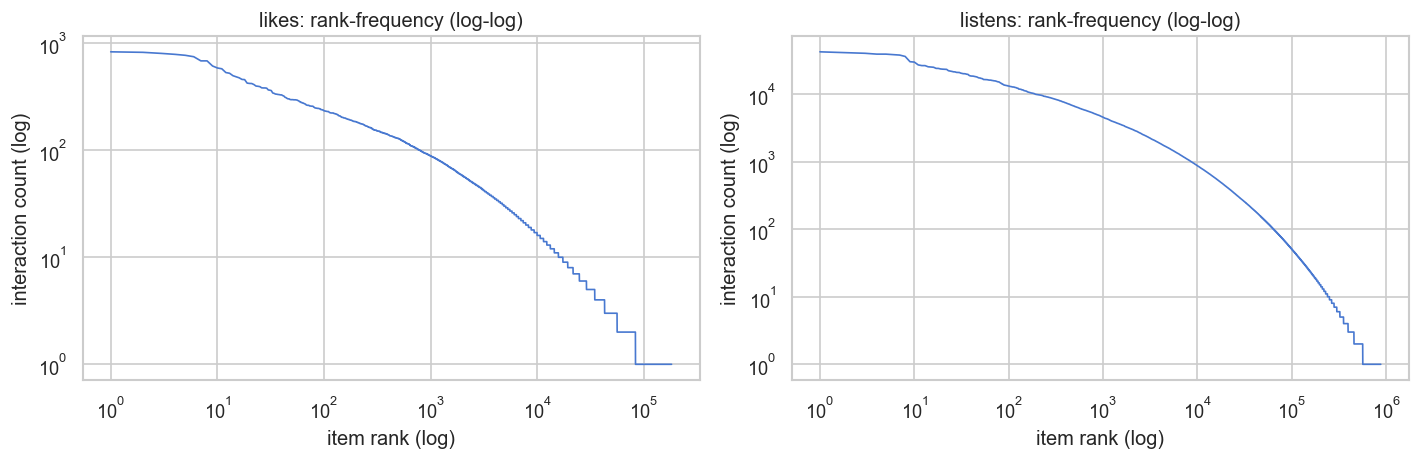

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df) in zip(axes, [("likes", likes), ("listens", listens)]):
    item_counts = df.groupby("item_id").size().sort_values(ascending=False).reset_index(drop=True)
    ax.loglog(item_counts.index + 1, item_counts.values, linewidth=1)
    ax.set_title(f"{name}: rank-frequency (log-log)")
    ax.set_xlabel("item rank (log)")
    ax.set_ylabel("interaction count (log)")

plt.tight_layout()
plt.show()

In [9]:
for name, df in [("likes", likes), ("listens", listens)]:
    item_counts = df.groupby("item_id").size().sort_values(ascending=False)
    total_interactions = item_counts.sum()

    cumsum = item_counts.cumsum()
    head_mask  = cumsum <= 0.20 * total_interactions
    torso_mask = (cumsum > 0.20 * total_interactions) & (cumsum <= 0.80 * total_interactions)
    tail_mask  = cumsum > 0.80 * total_interactions

    print(f"\n{name} \u2014 head/torso/tail (by cumulative interactions):")
    print(f"  Head  (top 20% interactions): {head_mask.sum():>6,} items  "
          f"({head_mask.sum() / len(item_counts):.1%} of catalog)")
    print(f"  Torso (20%-80% interactions): {torso_mask.sum():>6,} items  "
          f"({torso_mask.sum() / len(item_counts):.1%} of catalog)")
    print(f"  Tail  (bottom 20% interactions): {tail_mask.sum():>6,} items  "
          f"({tail_mask.sum() / len(item_counts):.1%} of catalog)")


likes — head/torso/tail (by cumulative interactions):
  Head  (top 20% interactions):  1,278 items  (0.7% of catalog)
  Torso (20%-80% interactions): 46,701 items  (25.8% of catalog)
  Tail  (bottom 20% interactions): 133,325 items  (73.5% of catalog)



listens — head/torso/tail (by cumulative interactions):
  Head  (top 20% interactions):  1,266 items  (0.1% of catalog)
  Torso (20%-80% interactions): 47,716 items  (5.4% of catalog)
  Tail  (bottom 20% interactions): 828,186 items  (94.4% of catalog)


## 5. Sparsity

In [10]:
for name, df in [("likes", likes), ("listens", listens)]:
    n_users = df["uid"].nunique()
    n_items = df["item_id"].nunique()
    n_interactions = len(df)
    density = n_interactions / (n_users * n_items)
    sparsity = 1 - density
    print(f"{name}:")
    print(f"  Users:        {n_users:>10,}")
    print(f"  Items:        {n_items:>10,}")
    print(f"  Interactions: {n_interactions:>10,}")
    print(f"  Density:      {density:.6%}")
    print(f"  Sparsity:     {sparsity:.6%}\n")

likes:
  Users:             8,283
  Items:           181,304
  Interactions:    881,456
  Density:      0.058696%
  Sparsity:     99.941304%



listens:
  Users:             9,238
  Items:           877,168
  Interactions: 46,467,212
  Density:      0.573437%
  Sparsity:     99.426563%



## 6. Temporal Patterns

Note: Yambda `timestamp` is delta-time in **5-second bins** (uint32), not absolute Unix time.

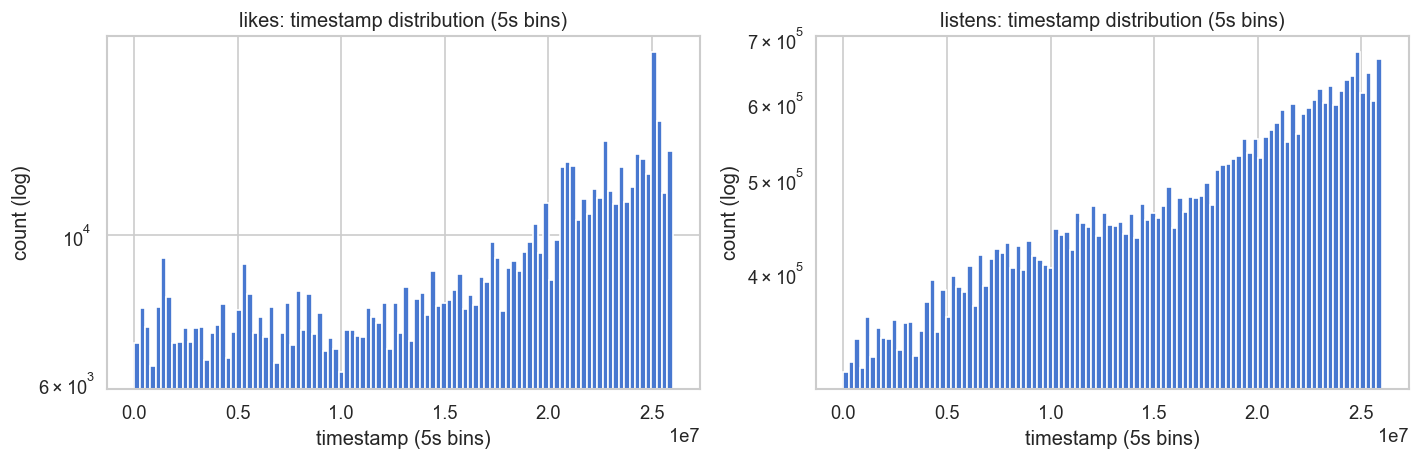

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df) in zip(axes, [("likes", likes), ("listens", listens)]):
    ax.hist(df["timestamp"], bins=100, log=True)
    ax.set_title(f"{name}: timestamp distribution (5s bins)")
    ax.set_xlabel("timestamp (5s bins)")
    ax.set_ylabel("count (log)")

plt.tight_layout()
plt.show()

In [12]:
for name, df in [("likes", likes), ("listens", listens)]:
    sorted_df = df.sort_values(["uid", "timestamp"])
    gaps = (sorted_df.groupby("uid")["timestamp"]
                     .diff()
                     .dropna())
    gaps_seconds = gaps * 5  # 5s bins -> seconds

    pcts = [50, 75, 90, 95, 99]
    print(f"\n{name} \u2014 inter-event gap percentiles (seconds):")
    print(pd.Series(np.percentile(gaps_seconds, pcts),
                    index=[f"p{p}" for p in pcts]).to_string())

    session_boundary_bins = 360  # 30 minutes
    n_sessions = (gaps > session_boundary_bins).sum() + df["uid"].nunique()
    print(f"  Estimated sessions (30-min gap): {n_sessions:,}")


likes — inter-event gap percentiles (seconds):
p50        2500.0
p75      313575.0
p90     1584635.0
p95     3236035.0
p99    11624897.0
  Estimated sessions (30-min gap): 470,990



listens — inter-event gap percentiles (seconds):


p50       725.0
p75      1100.0
p90      2000.0
p95     11075.0
p99    380725.0
  Estimated sessions (30-min gap): 5,083,339


## 7. Listens-Specific Features (`played_ratio_pct`, `is_organic`)

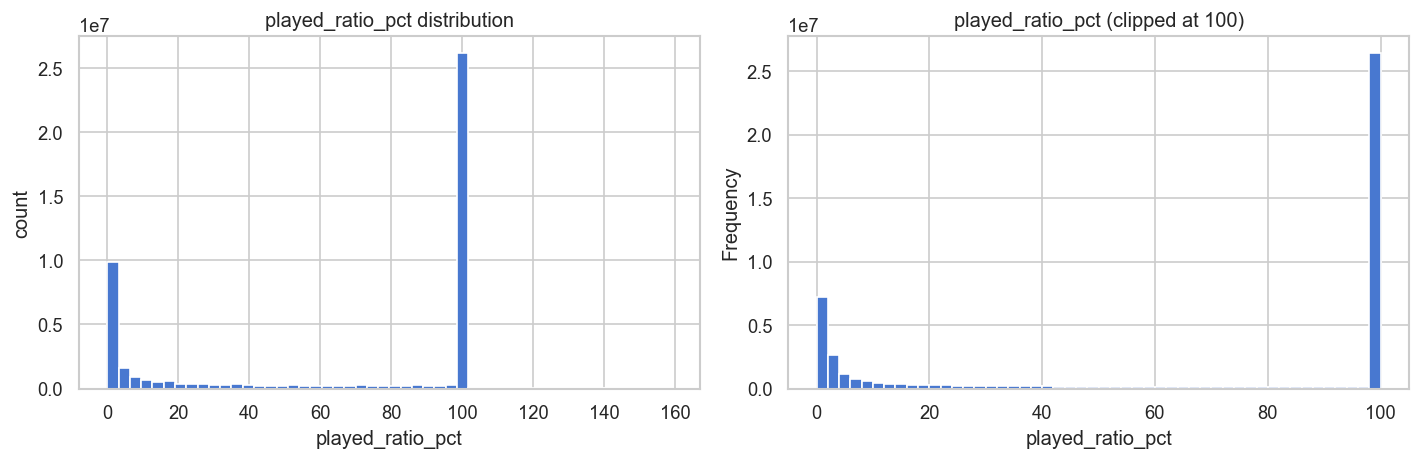

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(listens["played_ratio_pct"], bins=50)
ax.set_title("played_ratio_pct distribution")
ax.set_xlabel("played_ratio_pct")
ax.set_ylabel("count")

ax = axes[1]
listens["played_ratio_pct"].clip(upper=100).plot.hist(bins=50, ax=ax)
ax.set_title("played_ratio_pct (clipped at 100)")
ax.set_xlabel("played_ratio_pct")

plt.tight_layout()
plt.show()

In [14]:
for name, df in [("likes", likes), ("listens", listens)]:
    organic_pct = df["is_organic"].mean() * 100
    print(f"{name}: {organic_pct:.1f}% organic interactions")

print("\nlistens \u2014 played_ratio_pct by is_organic:")
print(listens.groupby("is_organic")["played_ratio_pct"].describe())

likes: 57.0% organic interactions
listens: 51.7% organic interactions

listens — played_ratio_pct by is_organic:


                 count       mean        std  min   25%    50%    75%    max
is_organic                                                                  
0           22463555.0  69.605375  42.513962  0.0  16.0  100.0  100.0  159.0
1           24003657.0  60.224515  45.042977  0.0   4.0   99.0  100.0  159.0


## 8. Summary & Recommendations

### Key Findings

| Metric | Likes | Listens |
|--------|-------|---------|
| Rows | 881,456 | 46,467,212 |
| Unique users | 8,283 | 9,238 |
| Unique items | 181,304 | 877,168 |
| Density | 0.0587% | 0.5734% |
| Median interactions/user | 44 | 3,024 |
| % organic | 57.0% | 51.7% |

### Positive-Label Definition

- **Likes** are explicit positive signals — use as ground truth for retrieval training.
- **Listens** with  as implicit positives for ranking (p25 = 7%, p50 = 100%; bimodal — most listens are either skipped or played to completion, so ≥50% captures genuine engagement).
- Users with fewer than **2** likes (p10 of user activity = 2 interactions) → cold-start bucket; exclude from retrieval eval.

### Preprocessing Thresholds

- **Min interactions per user (likes):** 2 (p10) — users with 1 like are too sparse for embedding training
- **Min interactions per item (likes):** 1 — 75% of catalog has only 1 like; use listens for item popularity signals instead
- **Session boundary:** 30 minutes (360 timestamp bins) — validated for listens (p90 gap ≈ 33 min); likes gaps are longer (p50 ≈ 42 min), suggesting likes are episodic, not session-based
- **Positive listen threshold:** 

### Data Quality

- **Nulls:** zero across all columns (both events)
- **Dtypes:** match documented schema (uid/item_id/timestamp uint32, is_organic uint8, played_ratio_pct uint16)
- **played_ratio_pct > 100:** values up to 159 observed (likely encoding artifact); clip to 100 for modeling
- **Item overlap:** likes catalog (181K items) is ~21% of listens catalog (877K items) — retrieval must cover the long tail


In [15]:
user_likes = likes.groupby("uid").size()
item_likes = likes.groupby("item_id").size()

print("=== Threshold Candidates ===")
print(f"\nUser min-interaction thresholds (likes):")
for pct in [5, 10, 25]:
    print(f"  p{pct}: {np.percentile(user_likes, pct):.0f} interactions")

print(f"\nItem min-interaction thresholds (likes):")
for pct in [5, 10, 25]:
    print(f"  p{pct}: {np.percentile(item_likes, pct):.0f} interactions")

print(f"\nPlayed-ratio positive thresholds (listens):")
for pct in [25, 50, 75]:
    print(f"  p{pct}: {np.percentile(listens['played_ratio_pct'], pct):.0f}%")

=== Threshold Candidates ===

User min-interaction thresholds (likes):
  p5: 1 interactions
  p10: 2 interactions
  p25: 10 interactions

Item min-interaction thresholds (likes):
  p5: 1 interactions
  p10: 1 interactions
  p25: 1 interactions

Played-ratio positive thresholds (listens):


  p25: 7%


  p50: 100%
  p75: 100%
